Este proyecto consiste en analizar una base de datos que contiene caracteristicas de personas a las que les fue otorgado un credito. La varaible objetivo es el estatus del credito otorgado. Esto permite predecir que tan buena idea es darle un credito a un nuevo cliente. Util en muchos sectores.

In [207]:
import pandas as pd

data = pd.read_csv('Loan_default.csv')
print(data.shape)

(255347, 18)


ANALISIS EXPLORATORIO DE DATOS

Primero clasificamos los datos

In [208]:
#Listas con los tipos de variables
s_feats = []
d_feats = []
c_feats = []

#Agregamos a las listas 
for col in data.columns:
    if data[col].dtype == 'str':
        s_feats.append(col)
    if data[col].dtype == 'int64':
        d_feats.append(col)
    if data[col].dtype == 'float64':
        c_feats.append(col)

#agregamos la inicila de tipo de variable
new_s_feats = ['s_' + x for x in s_feats]
new_d_feats = ['d_' + x for x in d_feats]
new_c_feats = ['c_' + x for x in c_feats]

data.rename(columns = dict(zip(s_feats, new_s_feats)), inplace = True)
data.rename(columns = dict(zip(d_feats, new_d_feats)), inplace = True)
data.rename(columns = dict(zip(c_feats, new_c_feats)), inplace = True)

print(data.info())


<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   s_LoanID          255347 non-null  str    
 1   d_Age             255347 non-null  int64  
 2   d_Income          255347 non-null  int64  
 3   d_LoanAmount      255347 non-null  int64  
 4   d_CreditScore     255347 non-null  int64  
 5   d_MonthsEmployed  255347 non-null  int64  
 6   d_NumCreditLines  255347 non-null  int64  
 7   c_InterestRate    255347 non-null  float64
 8   d_LoanTerm        255347 non-null  int64  
 9   c_DTIRatio        255347 non-null  float64
 10  s_Education       255347 non-null  str    
 11  s_EmploymentType  255347 non-null  str    
 12  s_MaritalStatus   255347 non-null  str    
 13  s_HasMortgage     255347 non-null  str    
 14  s_HasDependents   255347 non-null  str    
 15  s_LoanPurpose     255347 non-null  str    
 16  s_HasCoSigner     255347 non-nu

Analizamos la completitud de los datos

In [209]:
print(data.isnull().sum())

s_LoanID            0
d_Age               0
d_Income            0
d_LoanAmount        0
d_CreditScore       0
d_MonthsEmployed    0
d_NumCreditLines    0
c_InterestRate      0
d_LoanTerm          0
c_DTIRatio          0
s_Education         0
s_EmploymentType    0
s_MaritalStatus     0
s_HasMortgage       0
s_HasDependents     0
s_LoanPurpose       0
s_HasCoSigner       0
d_Default           0
dtype: int64


Eliminamos los duplicados

In [210]:
#Vemos cuantos tenemos
print(data.duplicated().sum())

#Anque no hay duplicados nos aseguramos
data = data.drop_duplicates()
print(data.shape)

0
(255347, 18)


Despues de esto, vemos que no es necesario rellenar NAs. Sin embargo es importante resaltar de que en caso de hacerlo, se debe verificar que los espacios vacios no sean mayores al 20% del total de registros en cada variable. Para hacerlo, normalmente se usa la mediana ya que en prescencia de outliers, no se sesga como el promedio.

NOTA PRO: Además de imputar, crearía una variable binaria indicando si el valor fue imputado o no

Exploramos las correlaciones

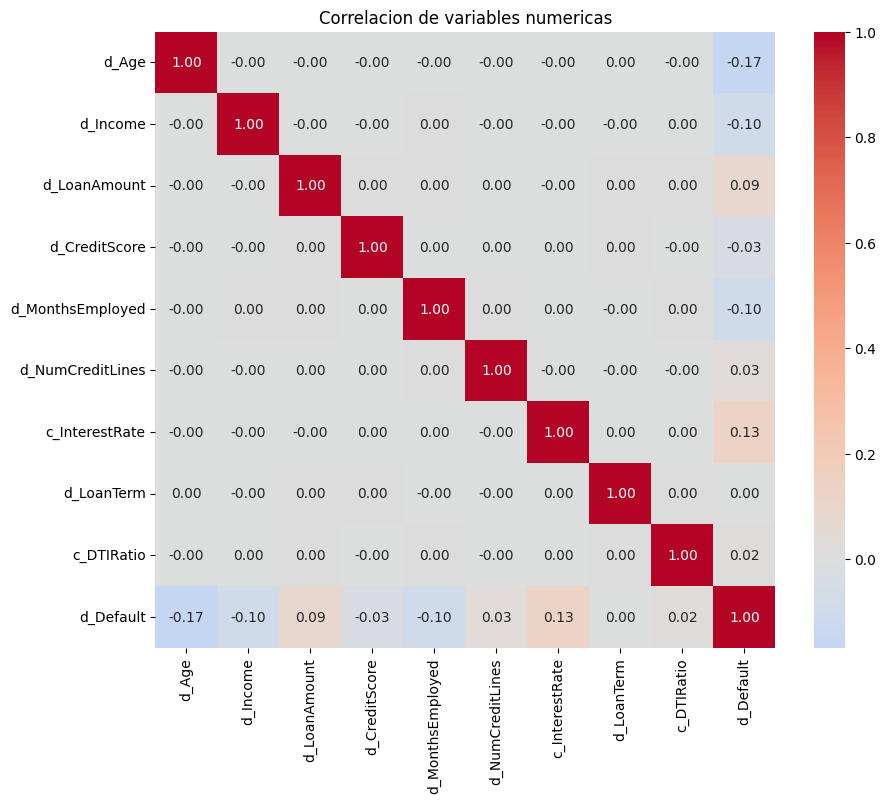

In [211]:
#Iniciamos con una grafica rapida de correlacion. Esto se hace entre las variables numericas y sirve para tener una idea basica de como se compartan las variables entre si,
#pero tampoco debe tomarse como guia unica para modificar el dataframe, ya que este tipo de correlaciones no capturan relaciones mas complejas, sobre todo en estos temas de credito.
num_var = []
for col in data.columns:
    if data[col].dtype == 'int64':
        num_var.append(col)
    if data[col].dtype == 'float64':
        num_var.append(col)

import matplotlib.pyplot as plt
import seaborn as sns

#Lo hacemos con un mapa de calor
corr = data[num_var].corr()
plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title('Correlacion de variables numericas')
plt.show()


Vemos como precisamente no hay multicolinealidad y todas las variables tienen un impacto en nuestra variable objetivo Defalut. Todo esto nos indica que una regresion lineal puede ser excelente modelo para predecir nuevos registros. Correlaciones debiles < 0.2

No existen relaciones lineales fuertes, lo cual sugiere que el fenómeno de default depende de interacciones más complejas y no lineales entre variables. Esto es normal en scoring crediticio.

Ahora exploramos cada variable

count    255347.000000
mean         43.498306
std          14.990258
min          18.000000
25%          31.000000
50%          43.000000
75%          56.000000
max          69.000000
Name: d_Age, dtype: float64


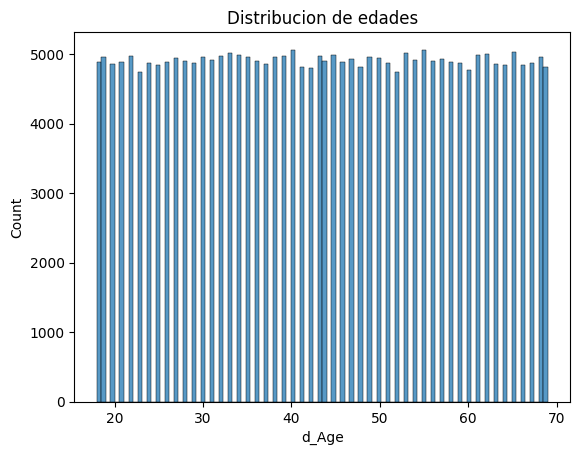

In [212]:
#El id solo sirve como primary key y no es util para utilizarla como variable numerica para entrenar modelos.
#Analicemos d_Age
data = data.drop(columns = 's_LoanID')

print(data['d_Age'].describe())
sns.histplot(x=data['d_Age'], bins=100)
plt.title('Distribucion de edades')
plt.show()

<Axes: xlabel='age_bin'>

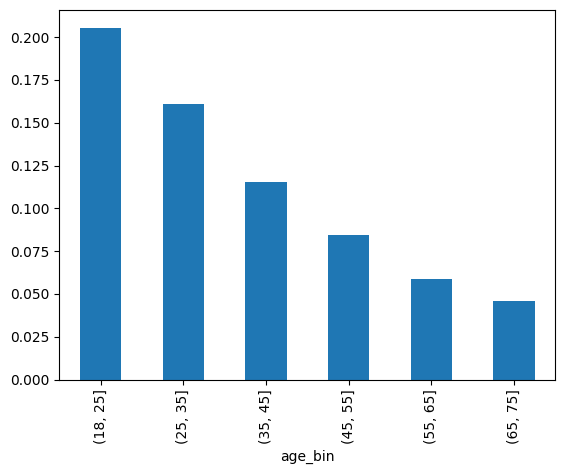

In [213]:
#La edad es muy importante en muchos sentidos, por lo que es interesante analizar su relacion con otras variables.
data['age_bin'] = pd.cut(data['d_Age'], bins=[18,25,35,45,55,65,75])
default_rate = data.groupby('age_bin')['d_Default'].mean()
default_rate.plot(kind='bar')

En cuestiones de credito un riesgo mayor al 15% es considerado alto. Uno mayor al 20% es muy alto riesgo

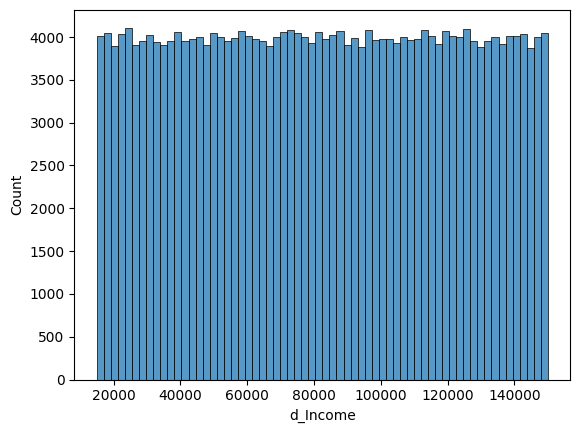

age_bin
(18, 25]    82687.921423
(25, 35]    82615.997166
(35, 45]    82128.889516
(45, 55]    82462.693904
(55, 65]    82596.607179
(65, 75]    82411.627540
Name: d_Income, dtype: float64


In [214]:
#Para el ingreso
sns.histplot(data['d_Income'])
plt.show()

data['age_range'] = pd.cut(data['d_Age'], bins=[18,25,35,45,55,65,75])
default_rate = data.groupby('age_bin')['d_Income'].mean()
print(default_rate)

In [215]:
#Veamos los outliers de ingresos
Q1 = data['d_Income'].quantile(0.25)
Q3 = data['d_Income'].quantile(0.75)
IQR = Q3 - Q1

outliers = data[(data['d_Income'] < Q1 - 1.5*IQR) | (data['d_Income'] > Q3 + 1.5*IQR)]
print(outliers)

Empty DataFrame
Columns: [d_Age, d_Income, d_LoanAmount, d_CreditScore, d_MonthsEmployed, d_NumCreditLines, c_InterestRate, d_LoanTerm, c_DTIRatio, s_Education, s_EmploymentType, s_MaritalStatus, s_HasMortgage, s_HasDependents, s_LoanPurpose, s_HasCoSigner, d_Default, age_bin, age_range]
Index: []


Vemos como el promedio de ingresos es bastante uniforme entre las distintas edades

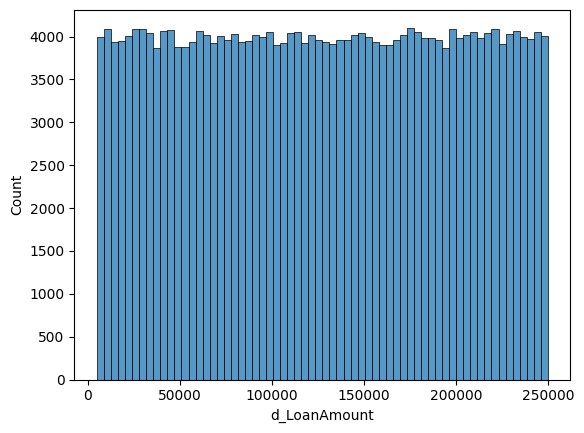

249999
5000


In [216]:
#Veamos loan amount
sns.histplot(data['d_LoanAmount'])
plt .show()
print(data['d_LoanAmount'].max())
print(data['d_LoanAmount'].min())

In [217]:
#Vemaos los ouliers del monto de los creditos
Q1 = data['d_LoanAmount'].quantile(0.25)
Q3 = data['d_LoanAmount'].quantile(0.75)
IQR = Q3-Q1

outliers = data[(data['d_LoanAmount'] < Q1-1.5*IQR)|(data['d_LoanAmount'] > Q3+IQR*1.5)]
print(outliers)

Empty DataFrame
Columns: [d_Age, d_Income, d_LoanAmount, d_CreditScore, d_MonthsEmployed, d_NumCreditLines, c_InterestRate, d_LoanTerm, c_DTIRatio, s_Education, s_EmploymentType, s_MaritalStatus, s_HasMortgage, s_HasDependents, s_LoanPurpose, s_HasCoSigner, d_Default, age_bin, age_range]
Index: []


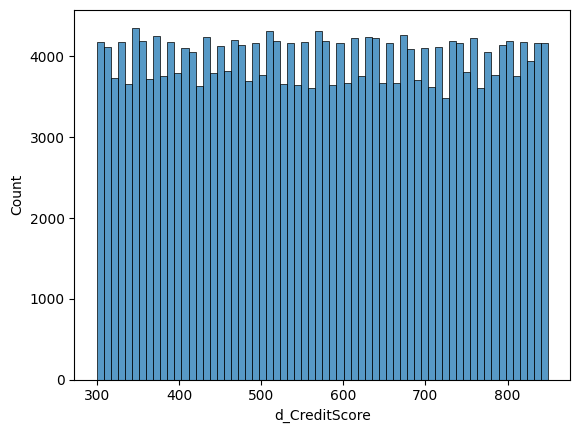

In [218]:
#Para credit score
sns.histplot(data['d_CreditScore'])
plt.show()

In [219]:
print(data['d_Default'].value_counts())

d_Default
0    225694
1     29653
Name: count, dtype: int64


Vemos que en general estamos tratando con un dataset muy uniformemente distribuido y sin outliers

Veamos que variables conviene hacer dummies

In [220]:
print(data['s_Education'].value_counts(dropna=False))
#Pocas categorias, las haremos dummies

s_Education
Bachelor's     64366
High School    63903
Master's       63541
PhD            63537
Name: count, dtype: int64


In [221]:
print(data['s_EmploymentType'].value_counts(dropna=False))
#Pocas categorias, las haremos dummies

s_EmploymentType
Part-time        64161
Unemployed       63824
Self-employed    63706
Full-time        63656
Name: count, dtype: int64


In [222]:
print(data['s_MaritalStatus'].value_counts(dropna=False))
#Pocas categorias, las haremos dummies

s_MaritalStatus
Married     85302
Divorced    85033
Single      85012
Name: count, dtype: int64


In [223]:
print(data['s_HasMortgage'].value_counts(dropna=False))
#Pocas categorias, las haremos dummies

s_HasMortgage
Yes    127677
No     127670
Name: count, dtype: int64


In [224]:
print(data['s_HasDependents'].value_counts(dropna=False))
#Pocas categorias, las haremos dummies

s_HasDependents
Yes    127742
No     127605
Name: count, dtype: int64


In [225]:
print(data['s_LoanPurpose'].value_counts(dropna=False))
#Pocas categorias, las haremos dummies

s_LoanPurpose
Business     51298
Home         51286
Education    51005
Other        50914
Auto         50844
Name: count, dtype: int64


In [226]:
print(data['s_HasCoSigner'].value_counts(dropna=False))
#Pocas categorias, las haremos dummies

s_HasCoSigner
Yes    127701
No     127646
Name: count, dtype: int64


Hacemos las dummies y las agregamos al datasey


In [227]:
data_encoded = pd.get_dummies(
    data,
    columns=['s_Education', 's_EmploymentType', 's_MaritalStatus', 's_HasMortgage','s_HasDependents', 's_LoanPurpose', 's_HasCoSigner'],
    drop_first=True
)
data_encoded.drop(columns = ['age_bin', 'age_range'], inplace = True)
print(data_encoded.info())

<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 25 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   d_Age                           255347 non-null  int64  
 1   d_Income                        255347 non-null  int64  
 2   d_LoanAmount                    255347 non-null  int64  
 3   d_CreditScore                   255347 non-null  int64  
 4   d_MonthsEmployed                255347 non-null  int64  
 5   d_NumCreditLines                255347 non-null  int64  
 6   c_InterestRate                  255347 non-null  float64
 7   d_LoanTerm                      255347 non-null  int64  
 8   c_DTIRatio                      255347 non-null  float64
 9   d_Default                       255347 non-null  int64  
 10  s_Education_High School         255347 non-null  bool   
 11  s_Education_Master's            255347 non-null  bool   
 12  s_Education_PhD            

Pasamos de 18 a 27 columnas despues de OHE

In [228]:
print(data_encoded.iloc[345,:])

d_Age                                 50
d_Income                          147122
d_LoanAmount                      139900
d_CreditScore                        832
d_MonthsEmployed                      63
d_NumCreditLines                       4
c_InterestRate                      6.21
d_LoanTerm                            60
c_DTIRatio                          0.61
d_Default                              0
s_Education_High School            False
s_Education_Master's               False
s_Education_PhD                     True
s_EmploymentType_Part-time          True
s_EmploymentType_Self-employed     False
s_EmploymentType_Unemployed        False
s_MaritalStatus_Married            False
s_MaritalStatus_Single              True
s_HasMortgage_Yes                   True
s_HasDependents_Yes                False
s_LoanPurpose_Business             False
s_LoanPurpose_Education            False
s_LoanPurpose_Home                  True
s_LoanPurpose_Other                False
s_HasCoSigner_Ye

Ahora hay que escalar nuestras variables numericas originales para que esten en la misma escala que las dummies. Sin embargo, no todos los modelos necesitan que las variables estén en la misma escala. El escalado importa cuando el modelo usa distancias, gradientes o productos internos. Si el modelo usa splits, no lo necesita.

Hagamos una REGRESION LOGISTICA

In [229]:
from sklearn.model_selection import train_test_split #Debemos dividir los datos antes de normalizarlos, para evitar que el modelo vea metricas que usan todos los datao (DATA LEAKAGE)
from sklearn.preprocessing import StandardScaler

#Separamos la variable target del dataset
x = data_encoded.drop(columns='d_Default')
y = data_encoded['d_Default']

#Dividimos las datos en 20% y 80%
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42) #stratify garantiza que se mantenga la proporcion de clases entre train set y test set


In [230]:
#Dividimos las columnas que necesitan ser escaladas de las que no
num_cols = [col for col in data_encoded.columns if not col.startswith('s_') and col != 'd_Default']
cat_cols = [col for col in data_encoded.columns if col.startswith('s_')]

In [231]:
#Armamos el procesador de datos
from sklearn.compose import ColumnTransformer

data_procesador = ColumnTransformer(
    transformers=[
        ('numericas', StandardScaler(), num_cols),
        ('categoricas', 'passthrough', cat_cols)
    ]
)

In [232]:
#Armamos la pipeline del modelo
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

modelo = Pipeline(
    steps=[
        ('procesamiento_datos', data_procesador),
        ('Regresion_logistica', LogisticRegression(
            class_weight='balanced', #resuelve el desbalance de clases y le da mas peso a la clase minoritaria
            max_iter = 1000))
    ]
)

modelo.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('procesamiento_datos', ...), ('Regresion_logistica', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('categoricas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the outp

In [233]:
#Ahora importamos las metricas para evaluar que tan bien predice el modelo
from sklearn.metrics import (roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay)

y_pred = modelo.predict(x_test) #Predice proba y asigna clase de acuerdo a umbral de 0.5
y_proba = modelo.predict_proba(x_test)[:,1] #Solo predice proba de la clase 1 (la que es default)

In [234]:
#Area debajo la curva, toma y_proba y todos los umbrales para clasificar las prediciones de y_proba en positivas o negativas. Con y_test se ve la validez de la prediccion.
roc_auc_sacore = roc_auc_score(y_test, y_proba)
print('ROC-AUC:' ,roc_auc_sacore)

ROC-AUC: 0.753180797586476


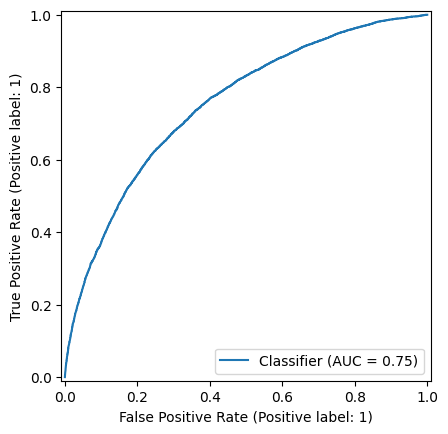

In [235]:
RocCurveDisplay.from_predictions(y_test, y_proba)

Tenemos muy buena ROC AUC, normalmente se busca una mayor a 0.65

In [236]:
#Reporte de metricas. En este caso nuestra metrica mas importante es Recall, ya que hay un gran desbalance de clases y los errores que mas nos interesan evitar son
#los falsos negativos (clientes que clasificamos como no entran en default pero realmente si lo hacen). Por nuestra precision en la clase 1, vemos que tenemos muchos falsos positivos
#es decir que nuestro modelo es conservador y con tal de no dejar pasar muchos falsos negativos, hace muchos falsos positivos (no da credito a muchas personas que si pagarian)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.67      0.79     45139
           1       0.22      0.70      0.33      5931

    accuracy                           0.68     51070
   macro avg       0.58      0.69      0.56     51070
weighted avg       0.86      0.68      0.73     51070



In [237]:
#Tenemos 30k TN, 14.7k FP, 1.7k FN, 4.1k TP.
confusion_matrix(y_test, y_pred)

array([[30393, 14746],
       [ 1781,  4150]])

In [238]:
#Vemos que si reducimos el umbral, obtenemos solo 505 FN (muy bueno), pero a costa de obtener muchos FP. Es decir, nuestro modelo se hace aun mas conservador.
#Nuestros creditos son muy seguros, pero no nos arriesgamos tanto y no tenemos tantas ganancias.
threshold = 0.3
y_pred_custom = (y_proba >= threshold).astype(int)

confusion_matrix(y_test, y_pred_custom)


array([[15071, 30068],
       [  505,  5426]])

RANDOM FOREST

En este tipo de modelos, un desicion tree suele sobreajustarse muy facil y ser muy inestable. El random forest evita estos problemas

In [239]:
#Obtenemos las variables y el target, para despues separar la info

x = data_encoded.drop(columns='d_Default')
y = data_encoded['d_Default']

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size= 0.2, stratify=y, random_state=42)

In [240]:
#Definimos y entrenamos el random forest
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=300, #numero de arboles
    max_depth= None, #profundidad maxima de cada arbol
    min_samples_split= 10, #minimo de observaciones para crear un split
    min_samples_leaf= 5, #Numero minimo de personas\regitros que debe tener cada hoja para que no subdivida a la bruto
    class_weight= 'balanced', #Ajusta el peso de cada clase en la función de pérdida
    random_state=42,
    n_jobs=-1 #Usa todos los cores del CPU. No matemático, solo eficiencia computacional
)

random_forest.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri